In [9]:
# ── Imports ──────────────────────────────────────────────────────────────
import kagglehub                                # Helper to download datasets straight from Kaggle
import os                                       # For working with file paths and folders
import tensorflow as tf                         # The deep-learning framework we build/train the model with
from tensorflow.keras import layers, models     # Building blocks (layers) and containers (models) for the CNN
import matplotlib.pyplot as plt                 # For plotting images and training charts

# Download the brain-tumor MRI dataset from Kaggle.
# kagglehub caches it locally, so this only downloads once; `path` is the folder it lives in.
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))                         # Show what's inside — here it's the 'Training' and 'Testing' folders

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset
['Training', 'Testing']


In [10]:
# ── Hyperparameters ──────────────────────────────────────────────────────
# These are the "settings" for training. Keeping them in one place makes them easy to tweak.
BATCH_SIZE = 32      # How many images the model looks at before updating its weights once
IMAGE_SIZE = 256     # Every image is resized to 256x256 pixels so they all match
CHANNELS = 3         # Colour channels per image: 3 = RGB (red, green, blue)
EPOCHS = 50          # How many times the model goes through the ENTIRE training set

In [11]:
# ── Locate the train / test folders ──────────────────────────────────────
# os.path.join builds a valid path regardless of operating system (avoids hard-coding slashes).
training_path = os.path.join(path, 'Training')   # Folder with images used to TEACH the model
testing_path = os.path.join(path, 'Testing')     # Folder with images used to CHECK the model on unseen data

# Each of these prints the sub-folders — one per tumor type. The folder name IS the label.
print(os.listdir(training_path))
print(os.listdir(testing_path))

['pituitary', 'notumor', 'meningioma', 'glioma']
['pituitary', 'notumor', 'meningioma', 'glioma']


In [12]:
# ── Load images into TensorFlow datasets ─────────────────────────────────
# image_dataset_from_directory reads every image, resizes it, and auto-labels it
# based on which sub-folder it came from (e.g. everything in /glioma gets label "glioma").
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    training_path,
    shuffle = True,                       # Mix up the order so the model doesn't learn the folder sequence
    image_size = (IMAGE_SIZE, IMAGE_SIZE), # Resize every image to 256x256
    batch_size = BATCH_SIZE               # Group images into batches of 32
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    testing_path,
    shuffle = True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE

)

# Performance tweaks that speed up training without changing the data:
#   .cache()    keeps images in memory after the first epoch (no re-reading from disk)
#   .prefetch() prepares the next batch on the CPU while the GPU works on the current one
#   AUTOTUNE    lets TensorFlow pick the best buffer size automatically
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

Found 5600 files belonging to 4 classes.
Found 1600 files belonging to 4 classes.


Found 5600 files belonging to 4 classes.
Detected Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


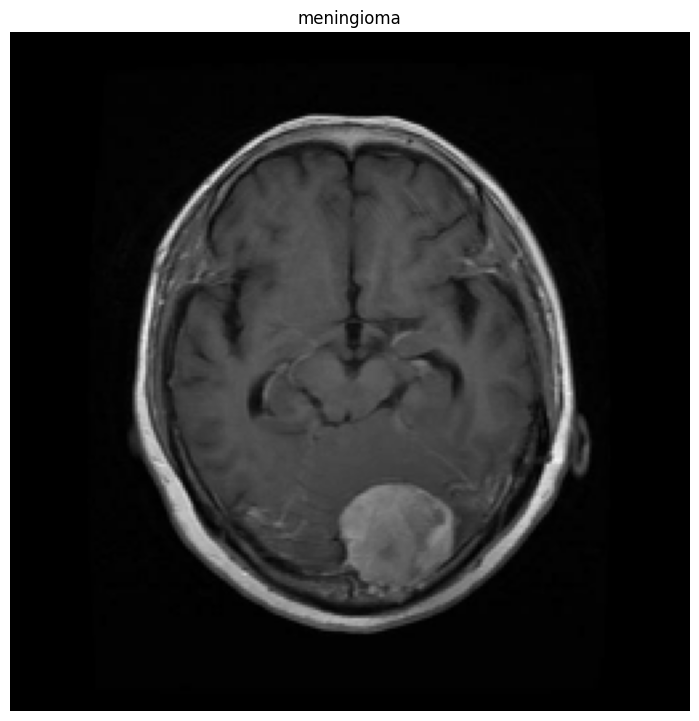

In [13]:
# ── Grab the class names and preview one image ───────────────────────────
# We reload the dataset here purely to read its `.class_names` (the list of tumor labels).
# NOTE: .class_names is lost once we cache/prefetch above, which is why a fresh copy is made.
temp_ds_for_names = tf.keras.preprocessing.image_dataset_from_directory(
    training_path,
    shuffle = True,
    image_size = (IMAGE_SIZE, IMAGE_SIZE),
    batch_size = BATCH_SIZE
)
class_names = temp_ds_for_names.class_names          # e.g. ['glioma', 'meningioma', 'notumor', 'pituitary']
print(f"Detected Classes: {class_names}")

# Sanity check: display a sample image so we can confirm the data loaded correctly.
plt.figure(figsize=(30,30))

for images, labels in train_ds.take(1):              # take(1) = grab just the first batch
  for i in range(1):                                 # Show a single image from that batch
    ax = plt.subplot(3, 3, i+1)                      # Position it in a grid slot
    plt.imshow(images[i].numpy().astype("uint8"))    # Convert the tensor to a displayable image
    plt.title(class_names[labels[i]])                # Use the numeric label to look up the readable name
    plt.axis("off")                                  # Hide the x/y axis ticks

plt.show()

In [14]:
# Print the final list of class names. Their ORDER matters: the model's output
# neuron 0 corresponds to class_names[0], neuron 1 to class_names[1], and so on.
print(class_names)

['glioma', 'meningioma', 'notumor', 'pituitary']


In [ ]:
# ── Build the CNN (Convolutional Neural Network) ─────────────────────────
# A Sequential model is just a stack of layers, run top to bottom.
# The general idea: convolution layers extract visual features, then dense
# layers use those features to decide which tumor class the image belongs to.
model = models.Sequential([
    # Preprocessing baked into the model so it also applies at prediction time:
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),   # Guarantee every input is 256x256
    layers.Rescaling(1.0/255),                 # Scale pixel values from 0–255 down to 0–1 (helps training)

    # Conv2D = slides small filters over the image to detect patterns.
    # MaxPooling2D = shrinks the image by keeping only the strongest signal in each region
    # (makes the model faster and more robust to small shifts).

    # Block 1 — detect basic features like edges
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS)),
    layers.MaxPooling2D((2, 2)),

    # Block 2 — combine edges into simple shapes (curves, circles)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 3 — detect more complex textures (tumor-like patterns)
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 4 — deeper, more abstract features
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Block 5 — the deepest, most abstract features
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    # Flatten: turn the 2D feature maps into a single 1D list of numbers
    # so the regular (dense) layers can read them.
    layers.Flatten(),

    # Dense (fully-connected) layer: learns how to combine features into a decision.
    layers.Dense(64, activation='relu'),

    # Output layer: 4 neurons, one per class (glioma, meningioma, notumor, pituitary).
    # 'softmax' turns the 4 outputs into probabilities that add up to 1 (100%).
    # We use it because each image belongs to exactly ONE class.
    layers.Dense(4, activation='softmax')
])

# Tell Keras the exact input shape (batch, height, width, channels) and print
# a table of every layer, its output size, and how many parameters it has.
model.build(input_shape=(BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, CHANNELS))
model.summary()

In [ ]:
# ── Compile and train the model ──────────────────────────────────────────
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Callbacks are helpers that run automatically during training.

# Save the model to disk whenever validation accuracy improves,
# so we always keep a copy of the best-performing version.
checkpoint = ModelCheckpoint(
    "brain_tumor_custom_cnn.keras",
    monitor="val_accuracy",     # Watch accuracy on the test set
    save_best_only = True       # Only overwrite the file when it gets better
)

# Stop training early if validation accuracy hasn't improved for 10 epochs
# in a row — saves time and helps prevent overfitting.
earlystop = EarlyStopping(
    monitor="val_accuracy",
    patience=10,                # Number of "no improvement" epochs to tolerate
    verbose=1                   # Print a message when it stops
)

# Compile = configure HOW the model learns:
#   optimizer='adam'                         -> the algorithm that adjusts the weights
#   loss='sparse_categorical_crossentropy'   -> the error measure for integer-labelled multi-class problems
#   metrics=['accuracy']                     -> the score we want reported each epoch
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# fit() = the actual training loop. Returns a `history` object recording
# accuracy/loss for every epoch (used later to plot the learning curves).
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=test_ds,    # Checked against unseen data after each epoch
    verbose=1                   # Show the progress bar
)

# Save the final model (note: the callbacks above aren't passed to fit(),
# so this line is what actually writes the trained model to disk).
model.save("brain_tumor_custom_cnn.keras")

In [ ]:
# ── Plot the learning curves ─────────────────────────────────────────────
# These charts help you SEE how training went and spot overfitting
# (overfitting = training score keeps rising while validation score stalls or drops).
import matplotlib.pyplot as plt

# Pull the per-epoch numbers recorded during training.
acc = history.history['accuracy']            # Accuracy on the training data
val_acc = history.history['val_accuracy']    # Accuracy on the validation/test data

loss = history.history['loss']               # Error on the training data
val_loss = history.history['val_loss']       # Error on the validation/test data

epochs_range = range(EPOCHS)                  # X-axis: 0, 1, 2, ... up to EPOCHS

plt.figure(figsize=(12,6))

# Left chart: accuracy over time (higher is better)
plt.subplot(1, 2, 1)                          # 1 row, 2 columns, first slot
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Right chart: loss over time (lower is better)
plt.subplot(1, 2, 2)                          # 1 row, 2 columns, second slot
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

In [ ]:
# ── Final evaluation on the test set ─────────────────────────────────────
# This gives the single "headline" score: how well the model does on data
# it was validated against, reported as loss and accuracy.
print("Evaluating on Test Data...")
score = model.evaluate(test_ds)      # Returns a list: [loss, accuracy]

print(f"Test Loss: {score[0]:.4f}")           # score[0] = loss   (:.4f = 4 decimal places)
print(f"Test Accuracy: {score[1]*100:.2f}%")  # score[1] = accuracy, shown as a percentage

In [ ]:
# ── Confusion matrix ─────────────────────────────────────────────────────
# A confusion matrix shows WHERE the model gets confused: which true classes
# get predicted as which. A perfect model has all its counts on the diagonal.
import numpy as np
import seaborn as sns                              # Makes a nicer-looking heatmap
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt


y_pred = []   # Will hold the model's predicted class for each image
y_true = []   # Will hold the actual (correct) class for each image

print("Generating predictions...")
# Loop over every batch in the test set and collect predictions vs. truth.
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)       # 4 probabilities per image
    y_pred.extend(np.argmax(preds, axis=1))        # argmax = index of the highest probability = predicted class
    y_true.extend(labels.numpy())                  # The real labels for this batch


# Build the matrix: rows = actual class, columns = predicted class.
cm = confusion_matrix(y_true, y_pred)


# Draw it as an annotated heatmap.
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', # annot=True writes the counts; fmt='d' formats them as integers
            xticklabels=class_names,               # Label the axes with readable class names
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Save the trained model to a single .keras file. This bundles the architecture
# AND the learned weights, so it can be reloaded later without retraining.
model.save("brain_tumor_custom_cnn.keras")

In [ ]:
# ── Predict on a single new image ────────────────────────────────────────
# This shows how you'd USE the trained model on one MRI scan, start to finish.
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt


# Load the saved model back from disk (no need to retrain).
model = tf.keras.models.load_model('brain_tumor_custom_cnn.keras')


# Point this at the image you want to classify, and load it at the model's expected size.
img_path = 'Image Path'                              # TODO: replace with the path to a real image file
img = image.load_img(img_path, target_size=(256, 256))


# Convert the loaded image into a NumPy array of pixel numbers.
img_array = image.img_to_array(img)


# Quick sanity check on the pixel range — if max is 0 the image is all black/empty.
print(f"Min Pixel Value: {img_array.min()}")
print(f"Max Pixel Value: {img_array.max()}")


# Models expect a BATCH of images, so add a batch dimension: (256,256,3) -> (1,256,256,3).
img_batch = tf.expand_dims(img_array, 0)

# Run the prediction. `preds` holds the 4 class scores for this one image.
preds = model.predict(img_batch)
score = tf.nn.softmax(preds[0])                      # Convert scores to probabilities that sum to 1


# Print each class with its score and probability. (Local list here matches the
# model's output order — keep it consistent with `class_names` above.)
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
print("\nRaw Prediction Scores:")
for i, name in enumerate(class_names):
    print(f"{name}: {preds[0][i]:.4f}  (Probability: {score[i]*100:.2f}%)")


# Show the exact image the model saw. If it looks black here, the model is "blind"
# (bad path or empty file) and any prediction above is meaningless.
plt.imshow(img_array.astype("uint8"))
plt.title(f"Model Input (Max val: {img_array.max()})")
plt.axis("off")
plt.show()